In [18]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[0]  # importing functions from other folders
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64

az.style.use("arviz-darkgrid")


if '___laptop' in os.listdir('../'):
    # laptop folder
    folder = "../../_data/p-dengue/"
elif '___server' in os.listdir('../'):
    # server folder
    folder = "../../../../../data/lucaratzinger_data/p_dengue/"

%matplotlib inline
from scipy import stats

In [3]:
data_o = read_in(folder, admin=2, max_lag=6, dropna=True, end_year=2017, end_month=12)

In [4]:
m = 'NB intercept + urbanisation'
model = pm.Model()
with model:
    # Priors
    alpha = pm.Exponential("alpha", disp_sigma)
    intercept = pm.Normal("intercept", mu=intercept_mu, sigma=intercept_sigma)
    if urbanisation_name is not None:
        beta_u = pm.Normal("beta_u", mu=0, sigma=beta_u_sigma)

    # Link
    log_mu = intercept + pm.math.log(data['population'])
    if urbanisation_name is not None:
        log_mu += beta_u*data[urbanisation_name]

    # Likelihood
    y_obs = pm.NegativeBinomial('y_obs', mu=pm.math.exp(log_mu), alpha=alpha, observed=data['cases'])


model_dict[m] = model
centred_dict[m] = True
B_dict[m] = None

NameError: name 'disp_sigma' is not defined

In [5]:
data = data_o.copy()

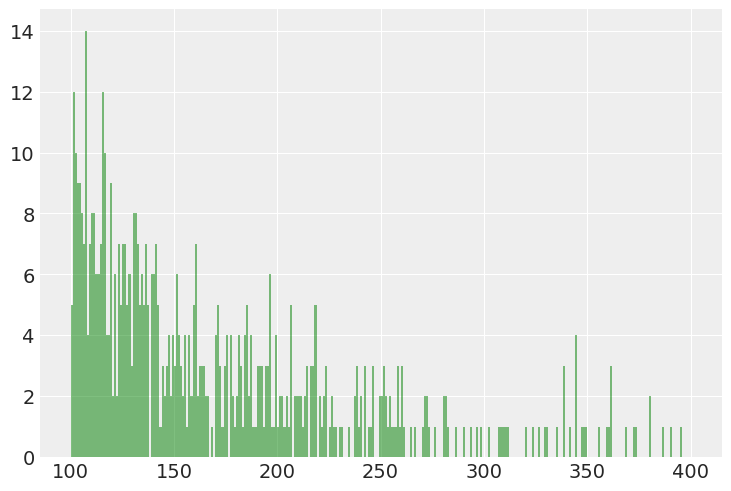

In [12]:
min_v = 100
max_v = 400
bins = np.arange(min_v, max_v + 1, 1)  # [0, 1, 2, ..., 100, 101]
plt.hist(data.loc[(data['cases'] < max_v) & (data['cases'] >= min_v), 'cases'], 
         bins=bins, density=False, alpha=0.5, color='g')
plt.show()

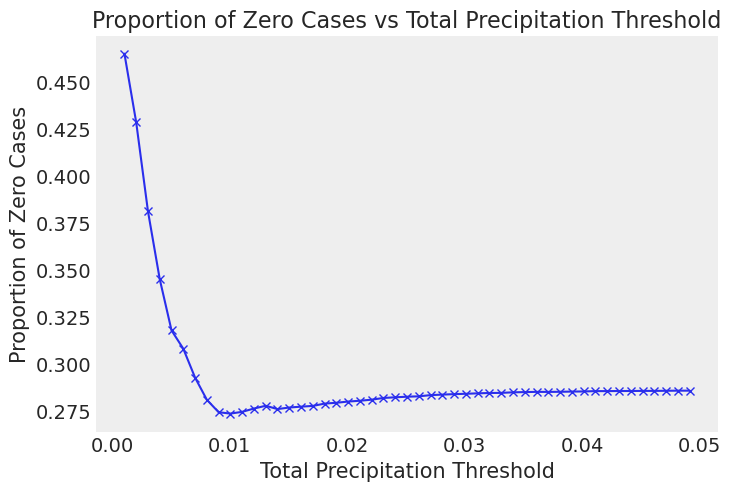

In [35]:
tp_min, tp_max = np.min(data_o['tp_24hmean_pop_weighted(1)']), np.max(data_o['tp_24hmean_pop_weighted(1)'])
tp_vals = np.linspace(tp_min, tp_max, 50)
zero_prop = []
for t in tp_vals:
    prop = np.mean(data_o.loc[data_o['tp_24hmean_pop_weighted(1)'] < t, 'cases'] == 0)
    zero_prop.append(prop)
plt.plot(tp_vals, zero_prop, marker='x')
plt.xlabel('Total Precipitation Threshold')
plt.ylabel('Proportion of Zero Cases')
plt.title('Proportion of Zero Cases vs Total Precipitation Threshold')
plt.grid()
plt.show()

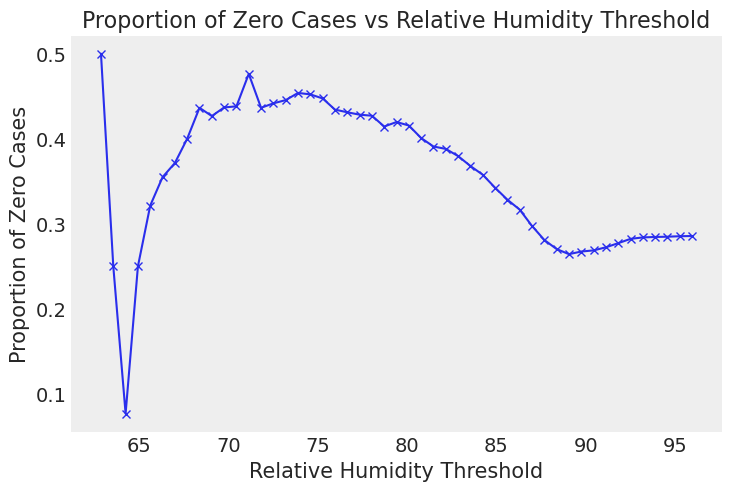

In [34]:
rh_min, rh_max = np.min(data_o['rh_mean_pop_weighted(0)']), np.max(data_o['rh_mean_pop_weighted(0)'])
rh_vals = np.linspace(rh_min, rh_max, 50)
zero_prop = []
for t in rh_vals:
    prop = np.mean(data_o.loc[data_o['rh_mean_pop_weighted(0)'] < t, 'cases'] == 0)
    zero_prop.append(prop)
plt.plot(rh_vals, zero_prop, marker='x')
plt.xlabel('Relative Humidity Threshold')
plt.ylabel('Proportion of Zero Cases')
plt.title('Proportion of Zero Cases vs Relative Humidity Threshold')
plt.grid()
plt.show()

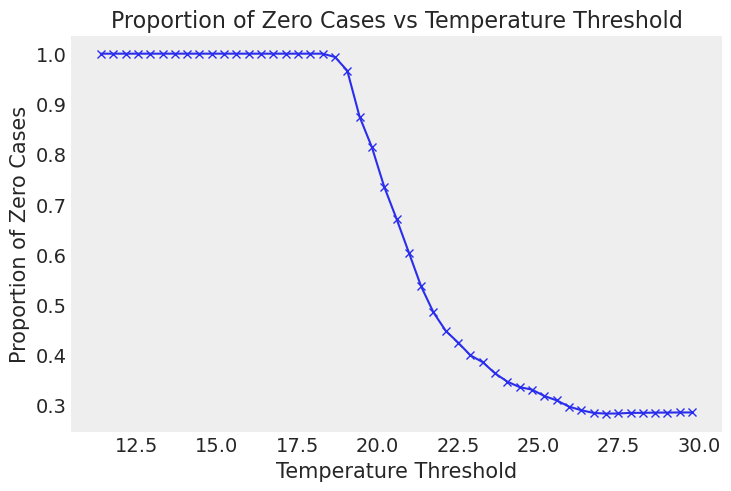

In [33]:
t_min, t_max = np.min(data_o['t2m_mean_pop_weighted(0)']), np.max(data_o['t2m_mean_pop_weighted(0)'])
t_vals = np.linspace(t_min, t_max, 50)
zero_prop = []
for t in t_vals:
    prop = np.mean(data_o.loc[data_o['t2m_mean_pop_weighted(0)'] < t, 'cases'] == 0)
    zero_prop.append(prop)
plt.plot(t_vals, zero_prop, marker='x')
plt.xlabel('Temperature Threshold')
plt.ylabel('Proportion of Zero Cases')
plt.title('Proportion of Zero Cases vs Temperature Threshold')
plt.grid()
plt.show()

In [29]:
data = data_o.loc[data_o['t2m_mean_pop_weighted(0)'] < 19.0, :]
print(np.mean(data['cases']==0))

0.9767441860465116


In [62]:
np.min(data['t2m_mean_pop_weighted(0)'])

11.015145829200094

In [14]:
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial, Poisson

# Offset: log(population) — enters the linear predictor (log scale)
offset = np.log(data['population'])

# Design matrix: intercept + urbanisation
X = sm.add_constant(data['urbanisation_pop_weighted_std'])
X.columns = ['intercept', 'beta_urbanisation']

# Fit model — alpha is jointly estimated via MLE
model = Poisson(
    endog=data['cases'],
    exog=X,
    offset=offset,    # log(mu) = log(population) + X*beta
)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 21.699532
         Iterations 5
                          Poisson Regression Results                          
Dep. Variable:                  cases   No. Observations:                11886
Model:                        Poisson   Df Residuals:                    11884
Method:                           MLE   Df Model:                            1
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                 0.01694
Time:                        06:26:52   Log-Likelihood:            -2.5792e+05
converged:                       True   LL-Null:                   -2.6237e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept           -10.2508      0.003  -3935.307      0.000     -10.256     -10.246
beta_ur

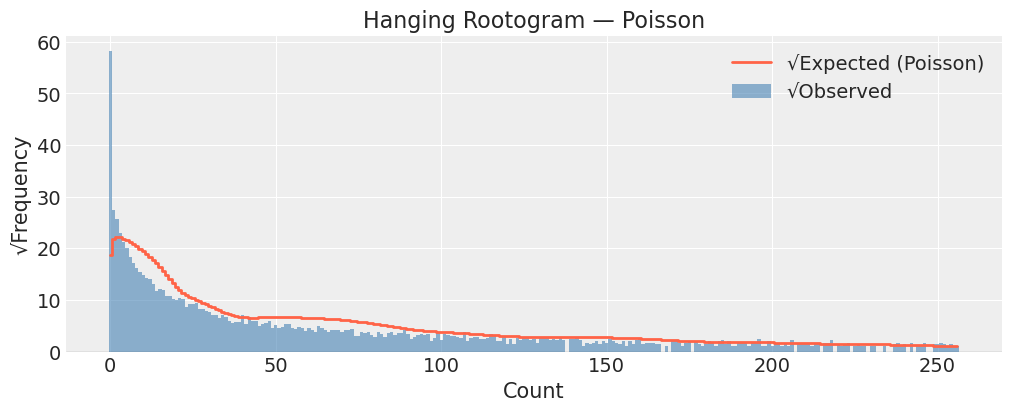

In [19]:
mu_hat = result.predict()
y = data['cases'].values

max_count = int(np.percentile(y, 99))
count_vals = np.arange(0, max_count + 1)

# Expected frequency under fitted Poisson
expected_freq = np.zeros(len(count_vals))
for mu_i in mu_hat:
    probs = stats.poisson.pmf(count_vals, mu=mu_i)
    expected_freq += probs

observed_freq = np.array([(y == k).sum() for k in count_vals])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(count_vals, np.sqrt(observed_freq), label='√Observed', color='steelblue', alpha=0.6, width=1.0)
ax.step(count_vals, np.sqrt(expected_freq), where='mid', color='tomato', lw=2, label='√Expected (Poisson)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Count'); ax.set_ylabel('√Frequency')
ax.set_title('Hanging Rootogram — Poisson'); ax.legend()
plt.show()

In [16]:
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial

# Offset: log(population) — enters the linear predictor (log scale)
offset = np.log(data['population'])

# Design matrix: intercept + urbanisation
X = sm.add_constant(data['urbanisation_pop_weighted_std'])
X.columns = ['intercept', 'beta_urbanisation']

# Fit model — alpha is jointly estimated via MLE
model = NegativeBinomial(
    endog=data['cases'],
    exog=X,
    offset=offset,    # log(mu) = log(population) + X*beta
    loglike_method='nb2'  # NB2: Var(y) = mu + alpha * mu^2
)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 3.478555
         Iterations: 11
         Function evaluations: 15
         Gradient evaluations: 15
                     NegativeBinomial Regression Results                      
Dep. Variable:                  cases   No. Observations:                11886
Model:               NegativeBinomial   Df Residuals:                    11884
Method:                           MLE   Df Model:                            1
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                0.001472
Time:                        06:26:59   Log-Likelihood:                -41346.
converged:                       True   LL-Null:                       -41407.
Covariance Type:            nonrobust   LLR p-value:                 2.405e-28
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
intercept            -9.

In [12]:
intercept_MLE = -9.9041
beta_urbanisation_MLE = 0.1775
alpha_MLE = 2.7305

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

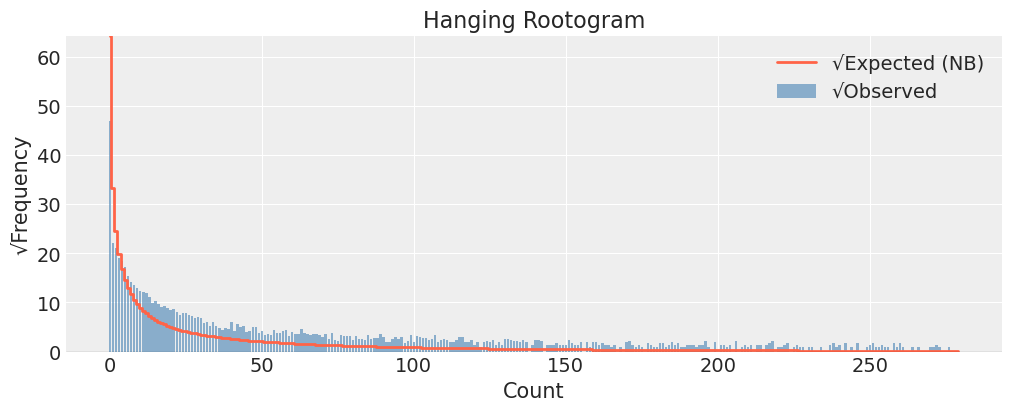

In [60]:
mu_hat = result.predict()          # statsmodels MLE predictions (includes offset)
alpha_hat = result.params['alpha'] # statsmodels alpha (dispersion)
y = data['cases'].values

# ── 1. Rootogram ────────────────────────────────────────────────────────────
# Best visual for count models: shows where model over/under-fits frequency
max_count = int(np.percentile(y, 99))  # avoid extreme outliers dominating
count_vals = np.arange(0, max_count + 1)

# Expected frequency under fitted NB for each observation, summed across obs
expected_freq = np.zeros(len(count_vals))
for mu_i in mu_hat:
    # NB2: p = alpha/(alpha + mu), n = 1/alpha  -- scipy parameterisation
    n_i = 1 / alpha_hat
    p_i = alpha_hat / (alpha_hat + mu_i)
    probs = stats.nbinom.pmf(count_vals, n=n_i, p=p_i)
    expected_freq += probs

observed_freq = np.array([(y == k).sum() for k in count_vals])

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(count_vals, np.sqrt(observed_freq), label='√Observed', color='steelblue', alpha=0.6)
ax.bar(count_vals, -np.sqrt(expected_freq) + np.sqrt(observed_freq),  # hanging bars
       bottom=np.sqrt(expected_freq), color='tomato', alpha=0.0)
ax.step(count_vals, np.sqrt(expected_freq), where='mid', color='tomato', lw=2, label='√Expected (NB)')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Count'); ax.set_ylabel('√Frequency')
ax.set_title('Hanging Rootogram'); ax.legend()
plt.show()

/tmp/ipykernel_4081298/1357567102.py:12: UserWarning: The figure layout has changed to tight
  ax.legend(); plt.tight_layout(); plt.show()


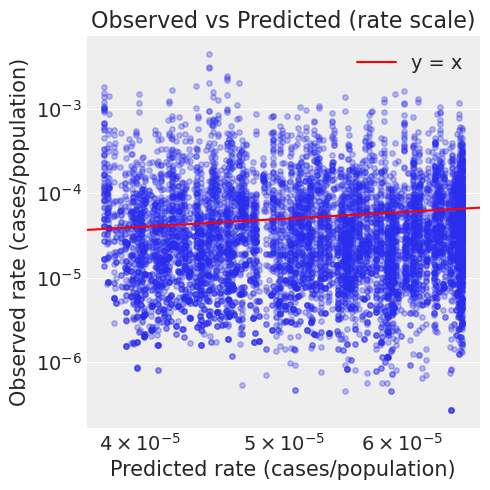

In [16]:
# ── 2. Observed vs Predicted (rate scale removes population effect) ──────────
rate_obs  = y / data['population'].values
rate_pred = mu_hat / data['population'].values

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(rate_pred, rate_obs, alpha=0.3, s=15)
ax.axline((0, 0), slope=1, color='red', lw=1.5, label='y = x')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Predicted rate (cases/population)')
ax.set_ylabel('Observed rate (cases/population)')
ax.set_title('Observed vs Predicted (rate scale)')
ax.legend(); plt.tight_layout(); plt.show()

/tmp/ipykernel_4081298/1945500771.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


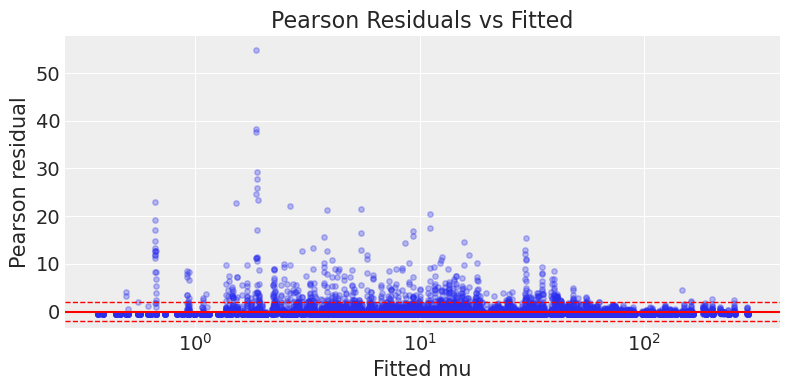

In [17]:
# ── 3. Pearson residuals vs predicted ───────────────────────────────────────
# NB2 variance: mu + alpha * mu^2
var_hat = mu_hat + alpha_hat * mu_hat**2
pearson_resid = (y - mu_hat) / np.sqrt(var_hat)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(mu_hat, pearson_resid, alpha=0.3, s=15)
ax.axhline(0, color='red', lw=1.5)
ax.axhline(2, color='red', lw=1, ls='--')
ax.axhline(-2, color='red', lw=1, ls='--')
ax.set_xscale('log')
ax.set_xlabel('Fitted mu'); ax.set_ylabel('Pearson residual')
ax.set_title('Pearson Residuals vs Fitted')
plt.tight_layout(); plt.show()